## Задание №1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Tzi — момент прихода заявки
# Tsi-1 — момент окончания предыдущего обслуживания
# dtw — допустимое время ожидания

In [2]:
def simulate_system(lambda_, mu, Tw_max, T):
    t = 0  # текущее время
    Ts_prev = 0  # момент окончания предыдущего обслуживания

    served = 0
    rejected = 0
    total_wait_time = 0
    idle_time = 0
    busy_time = 0

    arrival_times = []

    # Генерация потока заявок
    while t < T:
        dt = np.random.exponential(1 / lambda_)
        t += dt
        if t > T:
            break
        arrival_times.append(t)

    for Tzi in arrival_times:

        # допустимое время ожидания (равномерное распределение)
        dtw = np.random.uniform(0, Tw_max)
        deadline = Tzi + dtw

        # Вариант отказа
        if deadline < Ts_prev:
            rejected += 1
            continue

        # Вариант 2 — сервер свободен
        if Tzi >= Ts_prev:
            idle_time += Tzi - Ts_prev
            start_service = Tzi
        else:
            # Вариант 3 — ожидание
            wait = Ts_prev - Tzi
            total_wait_time += wait
            start_service = Ts_prev

        service_time = np.random.exponential(1 / mu)
        Ts_prev = start_service + service_time

        busy_time += service_time
        served += 1

    # Учитываем хвостовой простой: от последнего обслуживания до конца симуляции
    if Ts_prev < T:
        idle_time += T - Ts_prev

    total_requests = served + rejected

    results = {
        "served": served,
        "rejected": rejected,
        "p_served": served / total_requests if total_requests else 0,
        "p_rejected": rejected / total_requests if total_requests else 0,
        "idle_time": idle_time,
        "total_wait_time": total_wait_time,
        "avg_wait_time": total_wait_time / served if served else 0,
        "utilization": busy_time / T
    }

    return results

## Задание №2

In [3]:
lambda_ = 0.7 # интенсивность входного потока
mu = 0.8 # интенсивность обработки заявок
Tw_max = 1.0 # максимальное допустимое время ожидания
T = 1000 # суммарное время моделирования

result = simulate_system(lambda_, mu, Tw_max, T)

for key, value in result.items():
    print(f"{key}: {value:.4f}")

served: 419.0000
rejected: 286.0000
p_served: 0.5943
p_rejected: 0.4057
idle_time: 458.8619
total_wait_time: 24.5628
avg_wait_time: 0.0586
utilization: 0.5411


## Задание №3

In [4]:
Tw_values = np.linspace(0, 10, 50)

p_served_list = []
p_rejected_list = []
utilization_list = []
total_wait_list = []
avg_wait_list = []

for Tw in Tw_values:
    res = simulate_system(lambda_=0.7, mu=0.8, Tw_max=Tw, T=1000)

    p_served_list.append(res["p_served"])
    p_rejected_list.append(res["p_rejected"])
    utilization_list.append(res["utilization"])
    total_wait_list.append(res["total_wait_time"])
    avg_wait_list.append(res["avg_wait_time"])

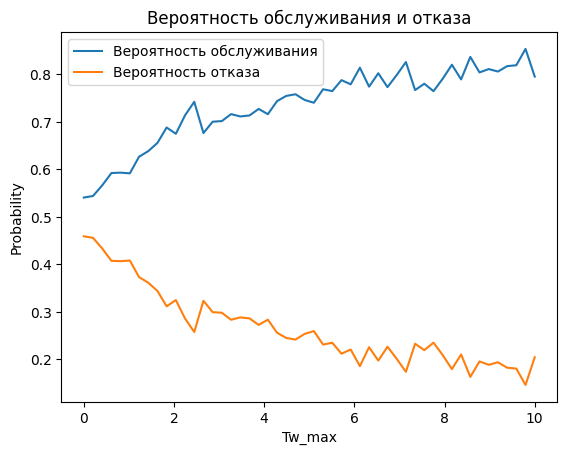

In [5]:
plt.figure()
plt.plot(Tw_values, p_served_list, label='Вероятность обслуживания')
plt.plot(Tw_values, p_rejected_list, label='Вероятность отказа')
plt.xlabel("Tw_max")
plt.ylabel("Probability")
plt.title("Вероятность обслуживания и отказа")
plt.legend()
plt.show()


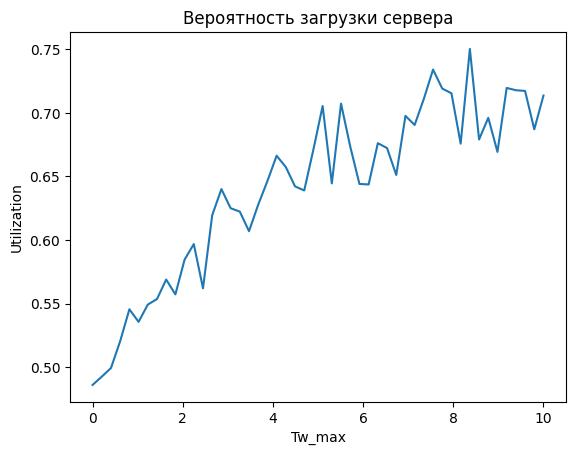

In [6]:
plt.figure()
plt.plot(Tw_values, utilization_list)
plt.xlabel("Tw_max")
plt.ylabel("Utilization")
plt.title("Вероятность загрузки сервера")
plt.show()

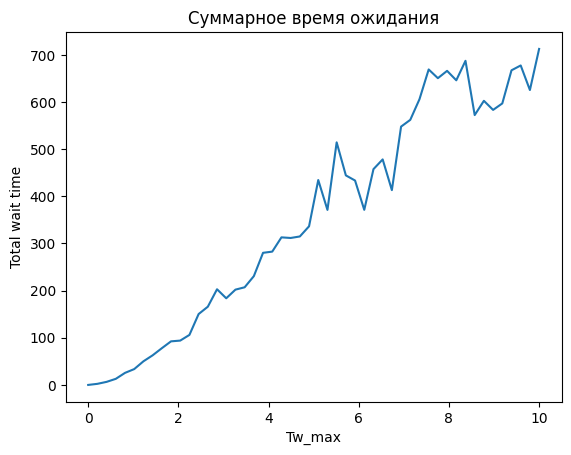

In [7]:
plt.figure()
plt.plot(Tw_values, total_wait_list)
plt.xlabel("Tw_max")
plt.ylabel("Total wait time")
plt.title("Суммарное время ожидания")
plt.show()

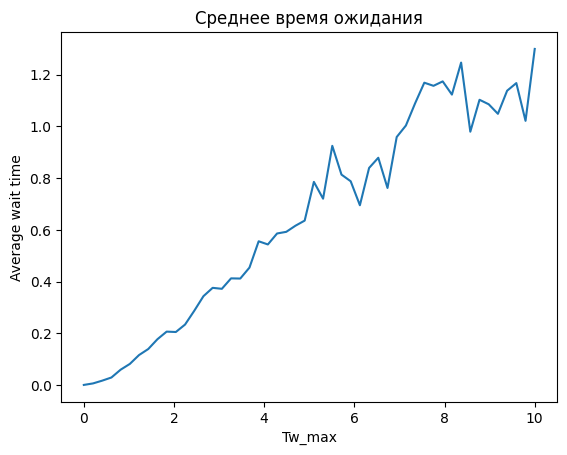

In [8]:
plt.figure()
plt.plot(Tw_values, avg_wait_list)
plt.xlabel("Tw_max")
plt.ylabel("Average wait time")
plt.title("Среднее время ожидания")
plt.show()

## Задание №4

In [9]:
optimal_Tw = None

for Tw in np.linspace(0, 10, 100):
    res = simulate_system(lambda_=0.7, mu=0.8, Tw_max=Tw, T=2000)

    print(f"Tw={Tw:.2f}, "
          f"P_served={res['p_served']:.3f}, "
          f"Util={res['utilization']:.3f}, "
          f"AvgWait={res['avg_wait_time']:.3f}")

    if (res["p_served"] >= 0.8 and
        res["utilization"] >= 0.6 and
        res["avg_wait_time"] <= 0.35):

        optimal_Tw = Tw
        break

print(optimal_Tw)

Tw=0.00, P_served=0.536, Util=0.465, AvgWait=0.000
Tw=0.10, P_served=0.542, Util=0.482, AvgWait=0.002
Tw=0.20, P_served=0.554, Util=0.494, AvgWait=0.005
Tw=0.30, P_served=0.544, Util=0.508, AvgWait=0.009
Tw=0.40, P_served=0.586, Util=0.484, AvgWait=0.017
Tw=0.51, P_served=0.594, Util=0.497, AvgWait=0.025
Tw=0.61, P_served=0.594, Util=0.513, AvgWait=0.034
Tw=0.71, P_served=0.570, Util=0.546, AvgWait=0.042
Tw=0.81, P_served=0.607, Util=0.527, AvgWait=0.046
Tw=0.91, P_served=0.612, Util=0.514, AvgWait=0.069
Tw=1.01, P_served=0.625, Util=0.534, AvgWait=0.084
Tw=1.11, P_served=0.620, Util=0.546, AvgWait=0.087
Tw=1.21, P_served=0.623, Util=0.547, AvgWait=0.107
Tw=1.31, P_served=0.637, Util=0.557, AvgWait=0.112
Tw=1.41, P_served=0.634, Util=0.553, AvgWait=0.130
Tw=1.52, P_served=0.637, Util=0.580, AvgWait=0.156
Tw=1.62, P_served=0.652, Util=0.579, AvgWait=0.176
Tw=1.72, P_served=0.649, Util=0.572, AvgWait=0.179
Tw=1.82, P_served=0.635, Util=0.589, AvgWait=0.185
Tw=1.92, P_served=0.657, Util=0